In [2]:
import pandas as pd

df = pd.read_csv("/content/Housing.csv")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
print(df.shape)

(545, 13)


In [7]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
print(df.mean(numeric_only=True))

price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935780e-01
dtype: float64


In [11]:
print(df.mode().iloc[0])

price                      3500000
area                        6000.0
bedrooms                       3.0
bathrooms                      1.0
stories                        2.0
mainroad                       yes
guestroom                       no
basement                        no
hotwaterheating                 no
airconditioning                 no
parking                        0.0
prefarea                        no
furnishingstatus    semi-furnished
Name: 0, dtype: object


In [12]:
print(df.var(numeric_only=True))

price        3.498544e+12
area         4.709512e+06
bedrooms     5.447383e-01
bathrooms    2.524757e-01
stories      7.525432e-01
parking      7.423300e-01
dtype: float64


In [13]:
print(df.std(numeric_only=True))

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64


In [14]:
print(df.skew(numeric_only=True))

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64


In [15]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [16]:
df.drop_duplicates(inplace=True)

In [17]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

In [18]:
correlation = df.corr()
print(correlation)

                     price      area  bedrooms  bathrooms   stories  mainroad  \
price             1.000000  0.535997  0.366494   0.517545  0.420712  0.296898   
area              0.535997  1.000000  0.151858   0.193820  0.083996  0.288874   
bedrooms          0.366494  0.151858  1.000000   0.373930  0.408564 -0.012033   
bathrooms         0.517545  0.193820  0.373930   1.000000  0.326165  0.042398   
stories           0.420712  0.083996  0.408564   0.326165  1.000000  0.121706   
mainroad          0.296898  0.288874 -0.012033   0.042398  0.121706  1.000000   
guestroom         0.255517  0.140297  0.080549   0.126469  0.043538  0.092337   
basement          0.187057  0.047417  0.097312   0.102106 -0.172394  0.044002   
hotwaterheating   0.093073 -0.009229  0.046049   0.067159  0.018847 -0.011781   
airconditioning   0.452954  0.222393  0.160603   0.186915  0.293602  0.105423   
parking           0.384394  0.352980  0.139270   0.177496  0.045547  0.204433   
prefarea          0.329777  

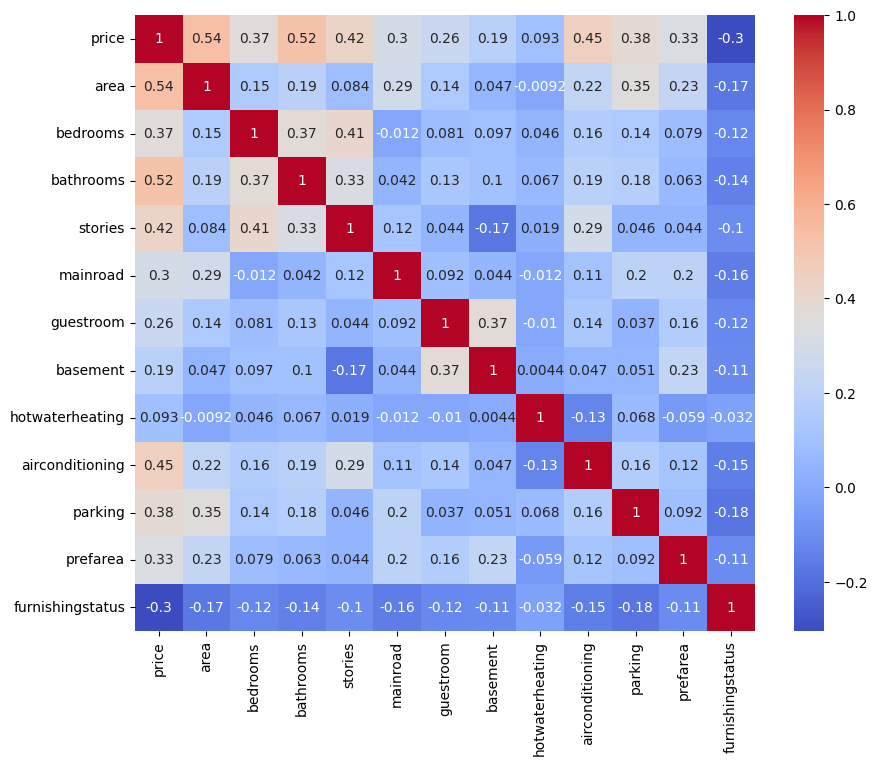

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

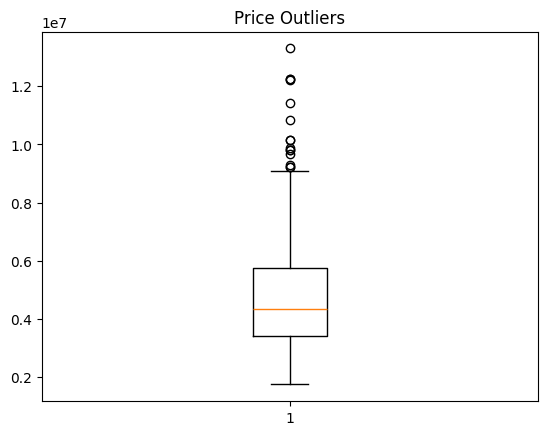

In [20]:
plt.boxplot(df["price"])
plt.title("Price Outliers")
plt.show()

In [21]:
print(df.corr()["price"].sort_values(ascending=False))

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64


In [22]:
x = df.drop("price", axis=1)
y = df["price"]

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [24]:
simple_x_train = x_train[["area"]]
simple_x_test = x_test[["area"]]

simple_model = LinearRegression()
simple_model.fit(simple_x_train, y_train)

simple_pred = simple_model.predict(simple_x_test)

In [25]:
multiple_model = LinearRegression()
multiple_model.fit(x_train, y_train)

multiple_pred = multiple_model.predict(x_test)

In [26]:
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
multiple_rmse = np.sqrt(mean_squared_error(y_test, multiple_pred))

simple_r2 = r2_score(y_test, simple_pred)
multiple_r2 = r2_score(y_test, multiple_pred)

results = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "RMSE": [simple_rmse, multiple_rmse],
    "R2 Score": [simple_r2, multiple_r2]
})

print(results)

                        Model          RMSE  R2 Score
0    Simple Linear Regression  1.917104e+06  0.272879
1  Multiple Linear Regression  1.331071e+06  0.649475


In [27]:
predictions = multiple_model.predict(x_test[:10])

prediction_df = pd.DataFrame({
    "Actual Price": y_test.iloc[:10].values,
    "Predicted Price": predictions
})

print(prediction_df)

   Actual Price  Predicted Price
0       4060000     5.203692e+06
1       6650000     7.257004e+06
2       3710000     3.062829e+06
3       6440000     4.559592e+06
4       2800000     3.332932e+06
5       4900000     3.563081e+06
6       5250000     5.645466e+06
7       4543000     6.413980e+06
8       2450000     2.755832e+06
9       3353000     2.668939e+06


In [28]:
joblib.dump(multiple_model, "house_price_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [29]:
loaded_model = joblib.load("house_price_model.pkl")
print("Model loaded successfully.")

Model loaded successfully.
